In [2]:
import os
import pandas as pd

DATASET_PATH = "../dataset"

emotion_dict = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}
data = []

#loop through the Actor folders

for actor_folder in os.listdir(DATASET_PATH):
    actor_path = os.path.join(DATASET_PATH, actor_folder)
    if os.path.isdir(actor_path):
        for file in os.listdir(actor_path):
            if file.endswith(".wav"):
                parts = file.split("-")
                emotion_code = parts[2]
                emotion = emotion_dict[emotion_code]
                file_path = os.path.join(actor_path, file)
                data.append({
                    "path": file_path,
                    "emotion": emotion,
                    "actor": actor_folder
                })


df = pd.DataFrame(data)
df.head()

,path,emotion,actor
0,../dataset\Actor_01\03-01-01-01-01-01-01.wav,neutral,Actor_01
1,../dataset\Actor_01\03-01-01-01-01-02-01.wav,neutral,Actor_01
2,../dataset\Actor_01\03-01-01-01-02-01-01.wav,neutral,Actor_01
3,../dataset\Actor_01\03-01-01-01-02-02-01.wav,neutral,Actor_01
4,../dataset\Actor_01\03-01-02-01-01-01-01.wav,calm,Actor_01


In [3]:
df["emotion"].value_counts()

emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64

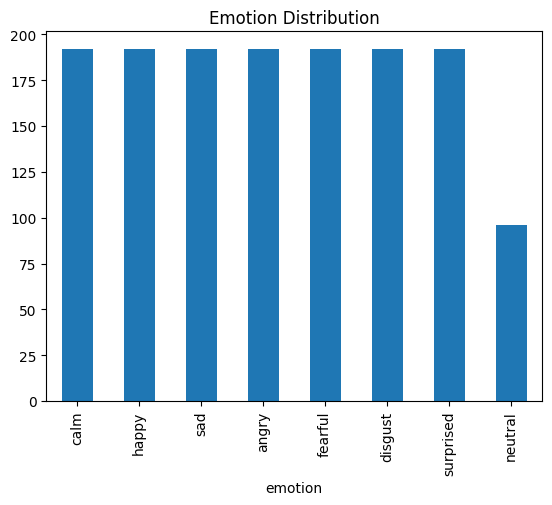

In [4]:
import matplotlib.pyplot as plt

df["emotion"].value_counts().plot(kind="bar")
plt.title("Emotion Distribution")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, stratify=df["emotion"],random_state=42
)

print(df.isnull().sum())

path       0
emotion    0
actor      0
dtype: int64


In [6]:
df.to_csv("../dataset_metadata.csv", index=False)